In [ ]:
!pip install livelossplot
!pip install torchmetrics[detection]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import shutil
import zipfile
import numpy as np
from PIL import Image
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from livelossplot import PlotLosses
from torch.optim.lr_scheduler import StepLR
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.transforms import v2
from torchvision import tv_tensors

In [ ]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/COMP646_Final_Project/BDD100K.zip'
local_zip = '/content/BDD100k.zip'
extract_to = 'content/BDD100K'

# copy zip to local storage.
shutil.copyfile(zip_path, local_zip)

# unzip.
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def visualize_sample(sample):
    img = Image.open(sample['file_path']).convert('RGB')
    fig, ax = plt.subplots(figsize=(15, 9))
    ax.imshow(img)

    for obj in sample['scene_objects']:
        label = obj['label']
        pts = obj['coordinates']

        # pts[0] = top left (x1, y1), pts[1] = bottom right [x2,y2]
        x_min, y_min = pts[0]
        x_max, y_max = pts[1]

        width, height = x_max - x_min, y_max - y_min

        # create the box
        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none')

        # create the label
        ax.text(x_min, y_min - 2, label, color='white', fontsize=9, bbox=dict(facecolor='red', alpha=0.5))

        ax.add_patch(rect)

    ax.set_xlim(0, 1280)
    ax.set_ylim(720, 0)
    plt.axis('off')
    plt.show()

In [ ]:
def load_bdd100k(split):
    merged_data = []

    base_path = "/content/content/BDD100K/BDD100K"

    image_dir = os.path.join(base_path, split, "img")
    annotation_dir = os.path.join(base_path, split, "ann")

    for file_name in os.listdir(image_dir):
        file_path = os.path.join(image_dir, file_name)

        with open(os.path.join(annotation_dir, f"{file_name}.json")) as file:
            json_annotations = json.load(file)
            cleaned_objects = []
            for obj in json_annotations["objects"]:
                cleaned_objects.append({
                    "coordinates": obj["points"]["exterior"],
                    "label": obj["classTitle"]
                })

        merged_data.append({
            "file_path": file_path,
            "scene_objects": cleaned_objects,
        })


    return merged_data

In [ ]:
train_data = load_bdd100k('train')
test_data = load_bdd100k('val')

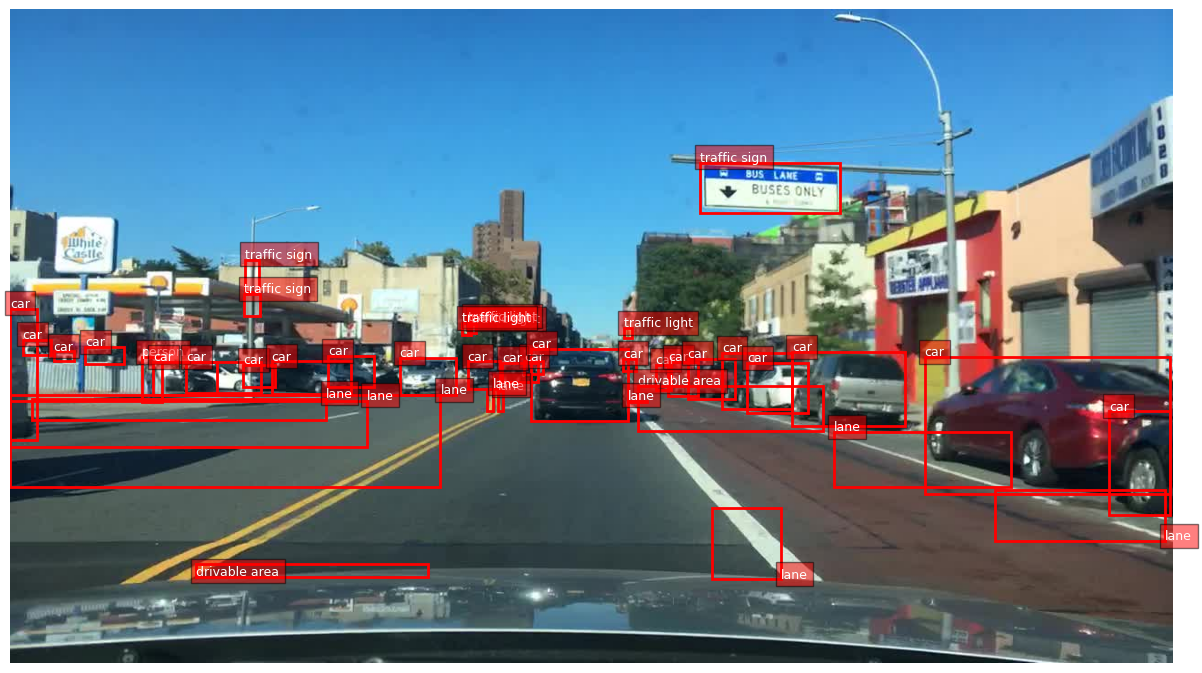

In [ ]:
# visualize a random training sample
visualize_sample(test_data[1272])

In [ ]:
class BDD100kDataset(Dataset):
    def __init__(self, data_list, label_map, img_size=(360, 640), is_train=True):
        self.data = data_list
        self.label_map = label_map
        self.img_size = img_size
        self.is_train = is_train

        # FasterRCNN PyTorch implementation normalizes the data such that the mean is zero.
        if self.is_train:
          self.transform = v2.Compose([
              v2.Resize(self.img_size),
              v2.RandomHorizontalFlip(p=0.5),
              v2.ToImage(),
              v2.ToDtype(torch.float32, scale=True)
          ])
        else:
          self.transform = v2.Compose([
              v2.Resize(self.img_size),
              v2.ToImage(),
              v2.ToDtype(torch.float32, scale=True)
          ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # 1. load the image.
        img = Image.open(item['file_path']).convert('RGB')
        orig_w, orig_h = img.size

        # 2. prepare boxes & labels.
        boxes = []
        labels = []
        for obj in item['scene_objects']:
            if obj['label'] not in self.label_map:
                continue

            pts = obj['coordinates']
            x_coords = [p[0] for p in pts]
            y_coords = [p[1] for p in pts]

            # scale coordinates into new pixel space.
            x_min, y_min = min(x_coords), min(y_coords)
            x_max, y_max = max(x_coords), max(y_coords)

            if x_min < x_max and y_min < y_max:
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(self.label_map[obj['label']])

        if not boxes:
            raw_boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            raw_boxes = torch.as_tensor(boxes, dtype=torch.float32)

        target_boxes = tv_tensors.BoundingBoxes(
            raw_boxes,
            format="XYXY",
            canvas_size=(orig_h, orig_w)
        )

        img_tensor, target_boxes = self.transform(img, target_boxes)
        target = {
            "boxes": target_boxes,
            "labels": torch.as_tensor(labels, dtype=torch.int64)
        }

        return img_tensor, target

In [ ]:
label_map = {
    'bike': 1,
    'bus': 2,
    'car': 3,
    'drivable area': 4,
    'lane': 5,
    'motor': 6,
    'person': 7,
    'rider': 8,
    'traffic light': 9,
    'traffic sign': 10,
    'train': 11,
    'truck': 12
}

train_dataset = BDD100kDataset(train_data, label_map)
test_dataset = BDD100kDataset(test_data, label_map)

def collate_fn(batch):
    """
    takes a list of tuples [(image, target)] and returns
    a tuple of lists ([image1, image2], [target1, target2])
    """
    return tuple(zip(*batch))

batch_size = 4
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

In [ ]:
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    # find how many features are going to the classifier.
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the existing classifier with a new untrained final layer.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
num_classes = len(label_map) + 1 # +1 for background class
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_model(num_classes)
model.to(device);

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 178MB/s]


In [ ]:
liveloss = PlotLosses(outputs=[MatplotlibPlot(save_to='current_loss_plot.png')])

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=8, gamma=0.5) # after 3 epochs, decrease LR by 90% each epoch

# train
num_epochs = 10
model.train()

quarter_mark = len(train_loader) // 4
liveloss_logs = {}

for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        # move images and targets to device.
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        current_loss = losses.item()
        epoch_loss += current_loss

        if i % 100 == 0:
          global_step = (epoch * len(train_loader)) + i
          liveloss_logs['loss'] = current_loss
          liveloss.update(liveloss_logs)
          liveloss.send()
          print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i}/{len(train_loader)}] [Batch Loss: {current_loss:.4f}]")

        if i > 0 and i % quarter_mark == 0:
          print("--- Quarter-epoch reached. Saving checkpoint... ---")
          print(f"Current loss: {current_loss}")
          checkpoint = {
              'epoch': epoch,
              'batch': i,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': losses.item()
          }
          file_name = f"BDD100K_quarter_epoch_{epoch+1}_{i}.pth"
          torch.save(checkpoint, file_name)
          plot_drive_path = f"/content/drive/MyDrive/COMP646_Final_Project/BDD100K_loss_ep{epoch+1}_batch{i}.png"
          shutil.copy('current_loss_plot.png', plot_drive_path)
          shutil.copy(file_name, f"/content/drive/MyDrive/COMP646_Final_Project/{file_name}")
          print("Checkpoint saved to Google Drive")

    scheduler.step()
    print(f"---Finished Epoch {epoch+1}, Avg Loss: {epoch_loss / len(train_loader):.4f} ---")

final_path = "bdd100k_faster_rcnn_final.pth"
torch.save(model.state_dict(), final_path)
shutil.copy(final_path, f"/content/drive/MyDrive/COMP646_Final_Project/{final_path}")

NameError: name 'PlotLosses' is not defined

<h3>Evaluating the Model</h3>

In [ ]:
metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

# load the trained model
weight_path = '/content/drive/MyDrive/COMP646_Final_Project/BDD100K_quarter_epoch_5_13125.pth'
checkpoint = torch.load(weight_path, map_location=device)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

with torch.no_grad():
  for images, targets in val_loader:
    images = [img.to(device) for img in images]
    predictions = model(images)
    cleaned_predictions = []
    for prediction in predictions:
      # if there are two boxes for the same class that overlap by more than 40%, only keep the one with the highest confidence score.
      keep = torchvision.ops.nms(prediction['boxes'], prediction['scores'], iou_threshold=0.7)
      cleaned_predictions.append({
        'boxes': prediction['boxes'][keep],
        'scores': prediction['scores'][keep],
        'labels': prediction['labels'][keep]
      })
    res_targets = [{k: v.to(device) for (k,v) in t.items()} for t in targets]
    metric.update(cleaned_predictions, res_targets)

final_map = metric.compute()

print("\n--- Validation Results ---")
print(f"mAP @ 0.50:0.95: {final_map['map']:.4f}")
print(f"mAP @ 0.50:      {final_map['map_50']:.4f}")
print(f"mAP @ 0.75:      {final_map['map_75']:.4f}")


--- Validation Results ---
mAP @ 0.50:0.95: 0.2513
mAP @ 0.50:      0.4571
mAP @ 0.75:      0.2335
